In [1]:
import pandas as pd
import os
import tweets_preprocessing as tp
from model import *

/Users/alalousis/PycharmProjects/AI_detector/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Please define the execution folder
# i.e. project_folder = "/Users/alalousis/PycharmProjects/AI_detector"
project_folder = "/Users/alalousis/PycharmProjects/AI_Detector_Project"
datasets_folder = f"{project_folder}/datasets"
results_folder = f"{project_folder}/results"
real_tweets_filename = "real_dataset.csv"
ai_tweets_filename = "ai_dataset_20000.csv"
real_tweets_df_size = 10000
ai_tweets_df_size = 10000

cols = [9]
real_tweets_df = pd.read_csv(os.path.join(datasets_folder, real_tweets_filename), encoding="UTF-8", header=0, usecols=cols)
real_tweets_df["created_by"] = "human"
real_tweets_df.head()
real_tweets_df.info()

cols = [1]
ai_tweets_df = pd.read_csv(os.path.join(datasets_folder, ai_tweets_filename), encoding="UTF-8", header=0, usecols=cols)
ai_tweets_df["created_by"] = "bot"
ai_tweets_df.head()
ai_tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238646 entries, 0 to 238645
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        238646 non-null  object
 1   created_by  238646 non-null  object
dtypes: object(2)
memory usage: 3.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        20000 non-null  object
 1   created_by  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [3]:
ai_tweets_df['text'] = ai_tweets_df['text'].str.strip('"')

In [4]:
main_dataset = pd.concat([real_tweets_df[:real_tweets_df_size], ai_tweets_df[:ai_tweets_df_size]], ignore_index=True)

In [5]:
main_dataset = main_dataset.sample(frac=1).reset_index(drop=True)

In [6]:
main_dataset = tp.clean_tweets(main_dataset)

In [7]:
import numpy as np

texts = list(main_dataset["cleaned_text"])
# texts = list(main_dataset["cleaned_text"])
L = [len(text) for text in texts]
NL = np.array(L)
# Compute the mean and the standard deviation of the sequence lengths.
Lmean,Lstd = NL.mean(),NL.std()
# labels = main_dataset["created_by"]
main_dataset['label'] = main_dataset['created_by'].apply(lambda x: 0 if x == 'human' else 1)
main_dataset.drop(columns=['created_by'], inplace=True)
labels = main_dataset["label"].to_list()

In [8]:
Labels = np.array(labels)
Labels_min = Labels.min()
Labels_max = Labels.max()
Labels_bins = np.arange(Labels_min,Labels_max+2)
LabelsHist,_ = np.histogram(Labels,Labels_bins)
class_priors = LabelsHist / LabelsHist.sum()

In [9]:
from transformers import BertTokenizer, BertModel

model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
bert_model = BertModel.from_pretrained(model_name)
max_length = int(Lmean+3*Lstd)+1

In [10]:
ground_truth_dataset = tp.SentimentDataset(texts, labels, tokenizer, max_length)

In [11]:
train_percent = 0.80
epochs = 5
batch_size = 2
freeze_bert = False
batch_save_period = 5
classes_num = len(set(labels))

In [12]:
from torch.utils.data import random_split, DataLoader

# Set the train and the test sizes.
train_size = int(train_percent * len(ground_truth_dataset))
test_size = len(ground_truth_dataset) - train_size

# Split the ground truth dataset into training and testing subsets.
train_dataset, test_dataset = random_split(
    ground_truth_dataset, [train_size,test_size])

# Instantiate the training and testing data loaders.
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size)


In [13]:
# -----------------------------------------------------------------------------
#    CLASSIFIER, LOSS FUNCTION, OPTIMIZER AND CHECK POINT INITIALIZATION:
# -----------------------------------------------------------------------------
# Set the device on which training will be performed.
device = get_execution_device()
model = SentimentClassifier(bert_model,classes_num,freeze_bert=freeze_bert)
optimizer = torch.optim.Adam(model.parameters(),lr=2e-5)
# Set the class weights to be inversly proportinal to the class priors.
class_weights = 1 / class_priors
# Convert class weights to tensor
weight = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weight)
# Move the initialized model to the appropriate device.
model = model.to(device)

MPS GPU is available!


In [14]:
# Define the name of the checkpoint directory
checkpoint_directory = f"checkpoints_{train_percent}_{epochs}_{batch_size}_{freeze_bert}_{batch_save_period}"
# Define the name of the file that will actually store the checkpoint dictionary.
checkpoint_filename = "model_checkpoint.pth"
# Create the full path for the checkpoint directory within the current directory
checkpoint_path = os.path.join(checkpoint_directory,checkpoint_filename)
# Set the number of batches within each training epoch after which a checkpoint
# entry will be saved.
batch_save_period = 5
# Create the checkpoint directory and the corresponding file in case it does
# not exist. In that case, create the file and save the initial state of the
# training process.
if not os.path.exists(checkpoint_directory):
    os.makedirs(checkpoint_directory)
    f = open(checkpoint_path,"w")
    f.close()
    # Set the initial state variables of the training process.
    epoch = 0
    batch_count=0
    model_state_dict = model.state_dict()
    optimizer_state_dict = optimizer.state_dict()
    train_accuracy = 0
    test_accuracy = 0
    torch.save({
        'epoch':epoch,
        'batch_count':batch_count,
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'train_accuracy':train_accuracy,
        'test_accuracy':test_accuracy
        },checkpoint_path)

100%|██████████| 8/8 [00:00<00:00, 15.61it/s]


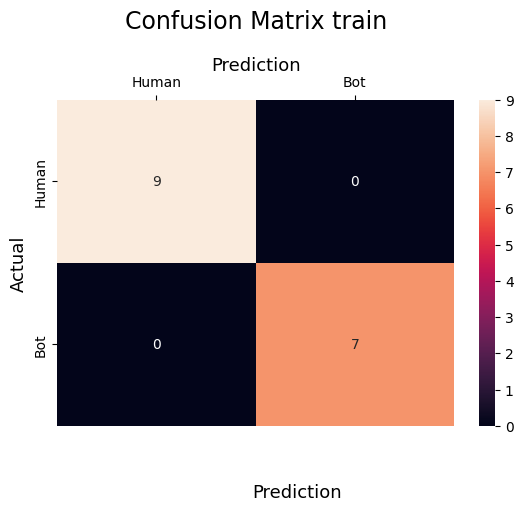

100%|██████████| 2/2 [00:00<00:00, 16.14it/s]


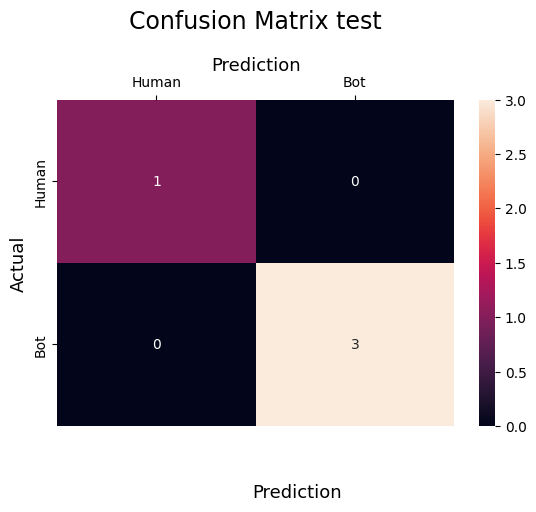

Training process completed


In [15]:
# Call the model training method.
train_model(model,train_loader,test_loader,optimizer,loss_fn,epochs, checkpoint_path=checkpoint_path, batch_save_period=batch_save_period, device=device, results_folder=results_folder)